# 7 · Gradient descent on a manifold with non-Euclidean geometry

Tutorial 3 hinted that the gradient depends on the inner product. Here we take that idea all
the way: we optimise over a **curved manifold** equipped with a **non-Euclidean metric**, and
the right search direction is the **Riemannian (natural) gradient** — the coordinate gradient
with its index raised by the inverse metric. In SpaceCore that index-raising is exactly
`space.riesz_inverse`, and the metric is supplied by a **custom `InnerProduct`**.

Our manifold is the unit sphere of a metric $M$,

$$ \mathcal{S}_M = \{\, x \in \mathbb{R}^3 : \langle x, x\rangle_M = x^\top M x = 1 \,\}, $$

(an ellipsoid in ordinary coordinates) and we minimise the linear objective
$f(x) = -\,t^\top x$ over it.

**You will learn to** write a custom geometry, build the Riemannian gradient with
`riesz_inverse`, and run constrained descent with a projection + retraction.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import spacecore as sc

# A clean, consistent palette + style for every figure in the tutorials.
BLUE, INDIGO, CYAN = "#2563eb", "#4f46e5", "#0891b2"
PINK, AMBER, GREEN = "#db2777", "#d97706", "#059669"
SLATE, GRID = "#334155", "#e5e9f0"

mpl.rcParams.update({
    "figure.figsize": (7.2, 4.2), "figure.dpi": 120, "savefig.dpi": 120,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": SLATE, "axes.linewidth": 1.0,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": SLATE,
    "axes.labelcolor": SLATE, "axes.labelsize": 11,
    "xtick.color": SLATE, "ytick.color": SLATE,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "font.size": 11,
    "legend.frameon": False, "legend.fontsize": 10,
    "lines.linewidth": 2.4, "lines.markersize": 6, "image.cmap": "magma",
})
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(
    color=[BLUE, PINK, GREEN, AMBER, INDIGO, CYAN])

print("spacecore", sc.__version__, "| numpy", np.__version__)

spacecore 0.4.0 | numpy 2.4.2


In [2]:
ctx = sc.Context(sc.NumpyOps(), dtype=np.float64)
ops = ctx.ops

## 1 · A custom metric is a custom `InnerProduct`

A geometry implements `inner` (and, to be useful for gradients, `riesz` / `riesz_inverse` —
the maps that lower and raise indices). Here is a constant SPD metric $\langle x,y\rangle = x^\top M y$;
its `riesz_inverse` is multiplication by $M^{-1}$, which is what turns a coordinate gradient
into the natural gradient.

In [3]:
from spacecore.space import InnerProduct

class MatrixInnerProduct(InnerProduct):
    """Constant SPD metric  <x, y> = xᵀ M y."""
    def __init__(self, M):
        self.M = np.asarray(M, dtype=float)
        self.Minv = np.linalg.inv(self.M)
    def inner(self, ops, x, y):       return ops.vdot(x, ops.matmul(ctx.asarray(self.M), y))
    def riesz(self, ops, x):          return ops.matmul(ctx.asarray(self.M), x)     # lower index
    def riesz_inverse(self, ops, x):  return ops.matmul(ctx.asarray(self.Minv), x)  # raise → nat. grad
    def validate_for(self, space):                                                   # light sanity check
        n = int(np.prod(space.shape))
        if self.M.shape != (n, n):
            raise ValueError(f"metric must be {n}x{n}, got {self.M.shape}")
    def convert(self, ctx):           return self
    @property
    def is_euclidean(self):           return False

M = np.array([[2.0, 0.6, 0.0],
              [0.6, 1.0, 0.0],
              [0.0, 0.0, 1.3]])
Sm = sc.DenseVectorSpace((3,), ctx, geometry=MatrixInnerProduct(M))

x = ctx.asarray([1.0, 0.0, 1.0]); y = ctx.asarray([0.0, 1.0, 1.0])
print("<x, y>_M           :", float(Sm.inner(x, y)), " (= xᵀ M y)")
print("riesz_inverse∘riesz:", Sm.riesz_inverse(Sm.riesz(x)), " (round-trips to x)")
print("is_euclidean       :", Sm.is_euclidean)

<x, y>_M           : 1.9  (= xᵀ M y)
riesz_inverse∘riesz: [1. 0. 1.]  (round-trips to x)
is_euclidean       : False


## 2 · Riemannian gradient descent

One step on the $M$-sphere has three parts:

1. **raise the index** — natural gradient $\nabla_M f = M^{-1}\partial f = $ `Sm.riesz_inverse(∂f)`;
2. **project onto the tangent space** $\{v : \langle x, v\rangle_M = 0\}$, using the $M$-inner product;
3. **retract** back onto the manifold by $M$-normalising.

We run it twice: once with the *natural* gradient (`riesz_inverse`), and once with the raw
coordinate gradient (the common bug of forgetting to raise the index, which is just Euclidean
steepest descent). Both descend, but on different paths.

In [4]:
t = ctx.asarray([0.6, 0.9, 0.4])          # objective f(x) = -tᵀx
f          = lambda x: -float(ops.vdot(t, x))
coord_grad = lambda x: -t                  # ∂f/∂x  (a covector)
m_normalize = lambda x: x / float(np.sqrt(Sm.inner(x, x)))

def riemannian_descent(use_natural, eta=0.35, n_steps=40):
    x = m_normalize(ctx.asarray([0.2, -0.9, 0.3]))
    xs, fs = [np.asarray(x).copy()], [f(x)]
    for _ in range(n_steps):
        g = Sm.riesz_inverse(coord_grad(x)) if use_natural else coord_grad(x)
        coef = Sm.inner(x, g) / Sm.inner(x, x)        # tangent projection (M-orthogonal)
        tan = g - coef * x
        x = m_normalize(x - eta * tan)                # gradient step + retraction
        xs.append(np.asarray(x).copy()); fs.append(f(x))
    return np.array(xs), np.array(fs)

path_nat, f_nat = riemannian_descent(use_natural=True)
path_euc, f_euc = riemannian_descent(use_natural=False)

# closed-form optimum of  max tᵀx  s.t.  xᵀMx = 1
x_star = np.linalg.solve(M, np.asarray(t)); x_star /= np.sqrt(x_star @ M @ x_star)
print("natural-grad final f :", f_nat[-1])
print("Euclidean-grad final f:", f_euc[-1])
print("optimal f*           :", -float(np.asarray(t) @ x_star))
print("on manifold? xᵀMx =", float(path_nat[-1] @ M @ path_nat[-1]))

natural-grad final f : -0.9670946411949166
Euclidean-grad final f: -0.861026308213982
optimal f*           : -0.9670946411950294
on manifold? xᵀMx = 1.0


## 3 · See it on the manifold

The $M$-unit sphere is an ellipsoid. We draw it, then trace both descent paths from the same
start to the same optimum (green star). The natural-gradient route (pink) honours the metric
and takes a more direct path than the metric-blind Euclidean route (blue).

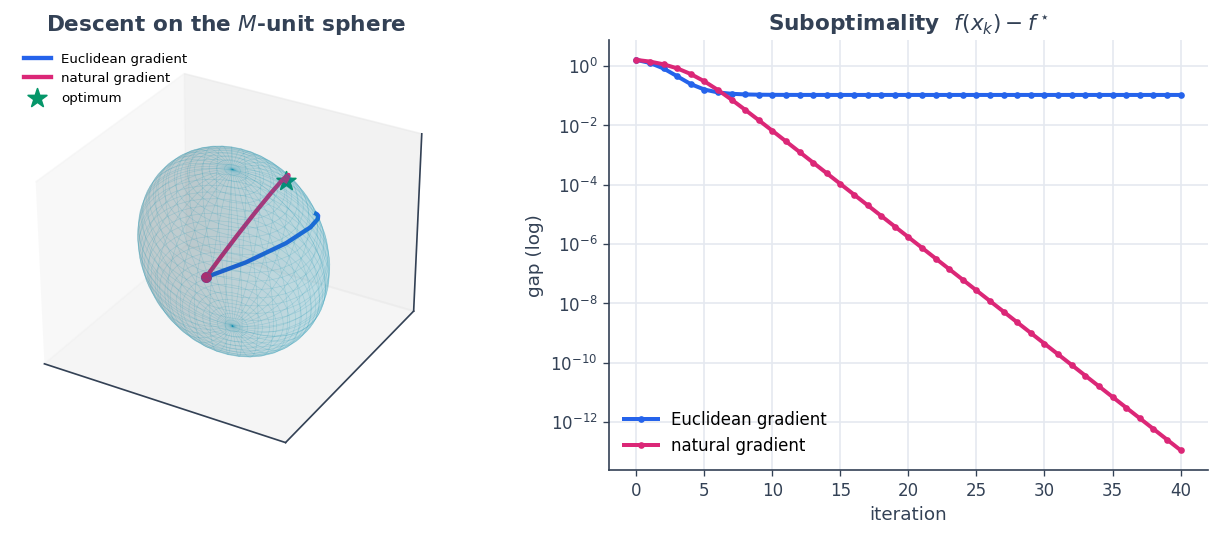

In [5]:
# ellipsoid surface: x = M^{-1/2} y for y on the Euclidean unit sphere
evals, evecs = np.linalg.eigh(M)
M_half_inv = evecs @ np.diag(evals ** -0.5) @ evecs.T
uu, vv = np.mgrid[0:np.pi:40j, 0:2*np.pi:40j]
sph = np.stack([np.sin(uu)*np.cos(vv), np.sin(uu)*np.sin(vv), np.cos(uu)])
ell = np.einsum("ij,jkl->ikl", M_half_inv, sph)

fig = plt.figure(figsize=(11, 4.6))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot_surface(ell[0], ell[1], ell[2], color=CYAN, alpha=0.12,
                linewidth=0, antialiased=True)
ax.plot_wireframe(ell[0], ell[1], ell[2], color=CYAN, alpha=0.18, linewidth=0.4)
for path, color, lab in [(path_euc, BLUE, "Euclidean gradient"),
                         (path_nat, PINK, "natural gradient")]:
    ax.plot(path[:, 0], path[:, 1], path[:, 2], color=color, lw=2.6, label=lab)
    ax.scatter(*path[0], color=color, s=30)
ax.scatter(*x_star, color=GREEN, s=140, marker="*", label="optimum")
ax.set_title("Descent on the $M$-unit sphere"); ax.legend(loc="upper left", fontsize=8)
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

ax2 = fig.add_subplot(1, 2, 2)
opt = -float(np.asarray(t) @ x_star)
ax2.semilogy(f_euc - opt + 1e-16, color=BLUE, marker="o", ms=3, label="Euclidean gradient")
ax2.semilogy(f_nat - opt + 1e-16, color=PINK, marker="o", ms=3, label="natural gradient")
ax2.set_title("Suboptimality  $f(x_k) - f^\\star$"); ax2.set_xlabel("iteration")
ax2.set_ylabel("gap (log)"); ax2.legend()
plt.tight_layout(); plt.show()

Both paths stay exactly on the ellipsoid (we checked $x^\top M x = 1$) and reach the same
optimum, but the natural gradient — built with a single call to `riesz_inverse` — gets there in
fewer, straighter steps. The metric is not a detail; it *is* the descent direction.

> **State-dependent metrics.** A `Space`'s geometry is fixed, so it models a *constant* metric.
> For a metric that varies with position (e.g. Fisher–Rao on the probability simplex, where
> $G(p)=\mathrm{diag}(1/p)$), rebuild a `WeightedInnerProduct` space at each iterate — the
> natural gradient is still just `riesz_inverse` of the coordinate gradient.

## Recap

* A non-Euclidean geometry is a **custom `InnerProduct`**: implement `inner`, `riesz`,
  `riesz_inverse`, `is_euclidean`, and `validate_for`.
* The **natural / Riemannian gradient** is `space.riesz_inverse(coordinate_gradient)` — raising
  the index with the inverse metric.
* Manifold descent = natural gradient → **tangent projection** → **retraction**; the metric
  shapes both the manifold and the path.

**Next:** [8 · PDHG for a conic program](08_pdhg_conic_program.ipynb) — operators, cones, and a
primal–dual saddle point.